# Projekat 3 — Veštačke neuronske mreže za klasifikaciju vremenskih uslova

Marija Cvetković 1940 \
Luka Kocić 2022

**Dataset:** [Weather Classification Data](https://www.kaggle.com/datasets/nikhil7280/weather-type-classification) — 13,200 uzoraka sa 10 ulaznih obeležja, klasifikacija po `Weather Type` (Cloudy, Rainy, Snowy, Sunny).

## 1. Učitavanje podataka

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

TensorFlow verzija: 2.21.0


In [2]:
df = pd.read_csv('weather_classification_data.csv')
print(f"Dimenzije dataseta: {df.shape}")
df.head(10)

Dimenzije dataseta: (13200, 11)


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
df.describe().round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00
mean,19.13,68.71,9.83,53.64,1005.83,4.01,5.46
std,17.39,20.19,6.91,31.95,37.20,3.86,3.37
min,-25.00,20.00,0.00,0.00,800.12,0.00,0.00
25%,4.00,57.00,5.00,19.00,994.80,1.00,3.00
50%,21.00,70.00,9.00,58.00,1007.65,3.00,5.00
75%,31.00,84.00,13.50,82.00,1016.77,7.00,7.50
max,109.00,109.00,48.50,109.00,1199.21,14.00,20.00


In [ ]:
print("Nedostajuće vrednosti po koloni:")
print(df.isnull().sum())
print(f"\nUkupno nedostajućih: {df.isnull().sum().sum()}")

Nedostajuće vrednosti po koloni:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Ukupno nedostajućih: 0


## 2. Deskriptivna analiza i vizuelizacija

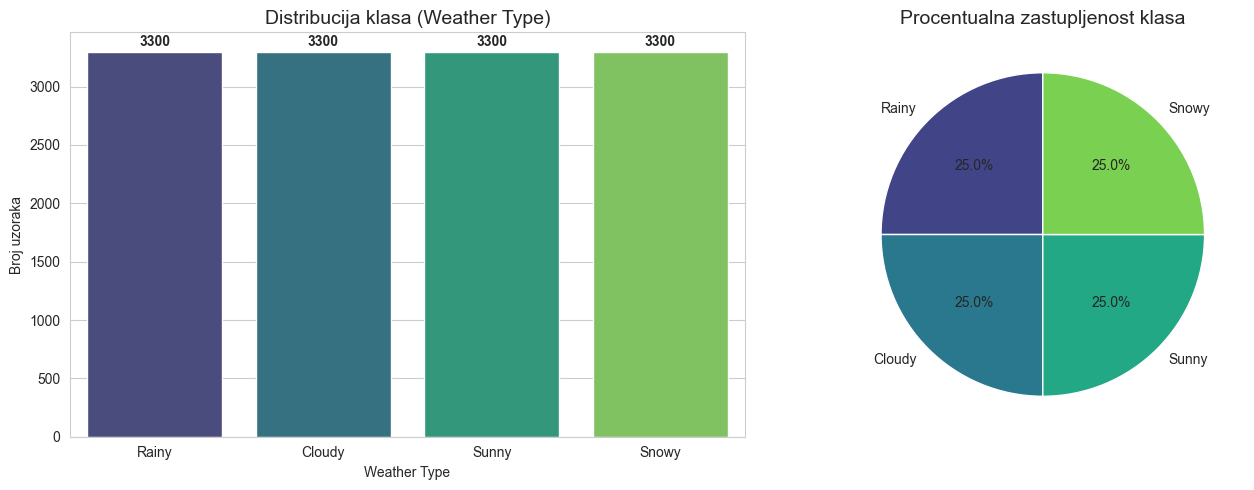

In [6]:
# Distribucija ciljne promenljive
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df['Weather Type'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribucija klasa (Weather Type)', fontsize=14)
axes[0].set_ylabel('Broj uzoraka')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', 4), startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa', fontsize=14)

plt.tight_layout()
plt.show()

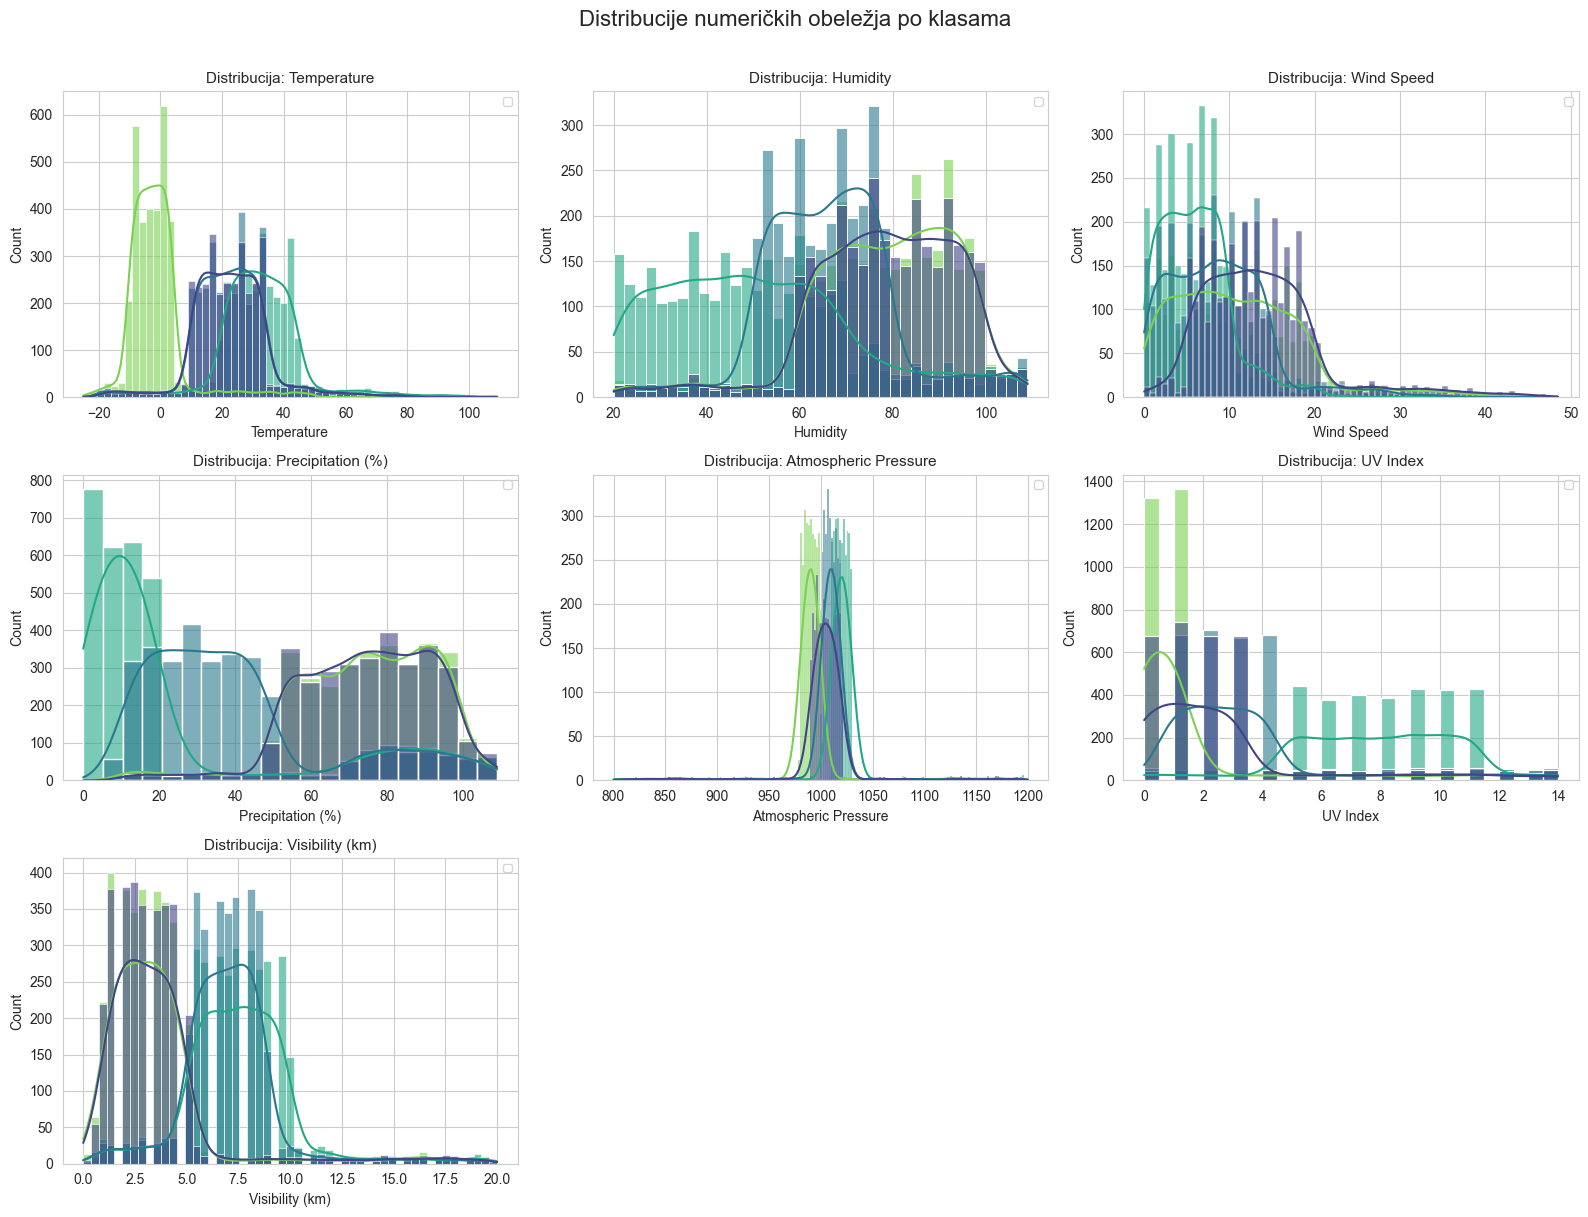

In [ ]:
numerical_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                  'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Weather Type', kde=True, ax=axes[i],
                 palette='viridis', alpha=0.6)
    axes[i].set_title(f'Distribucija: {col}', fontsize=11)
    axes[i].legend(fontsize=8)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucije numeričkih obeležja po klasama', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

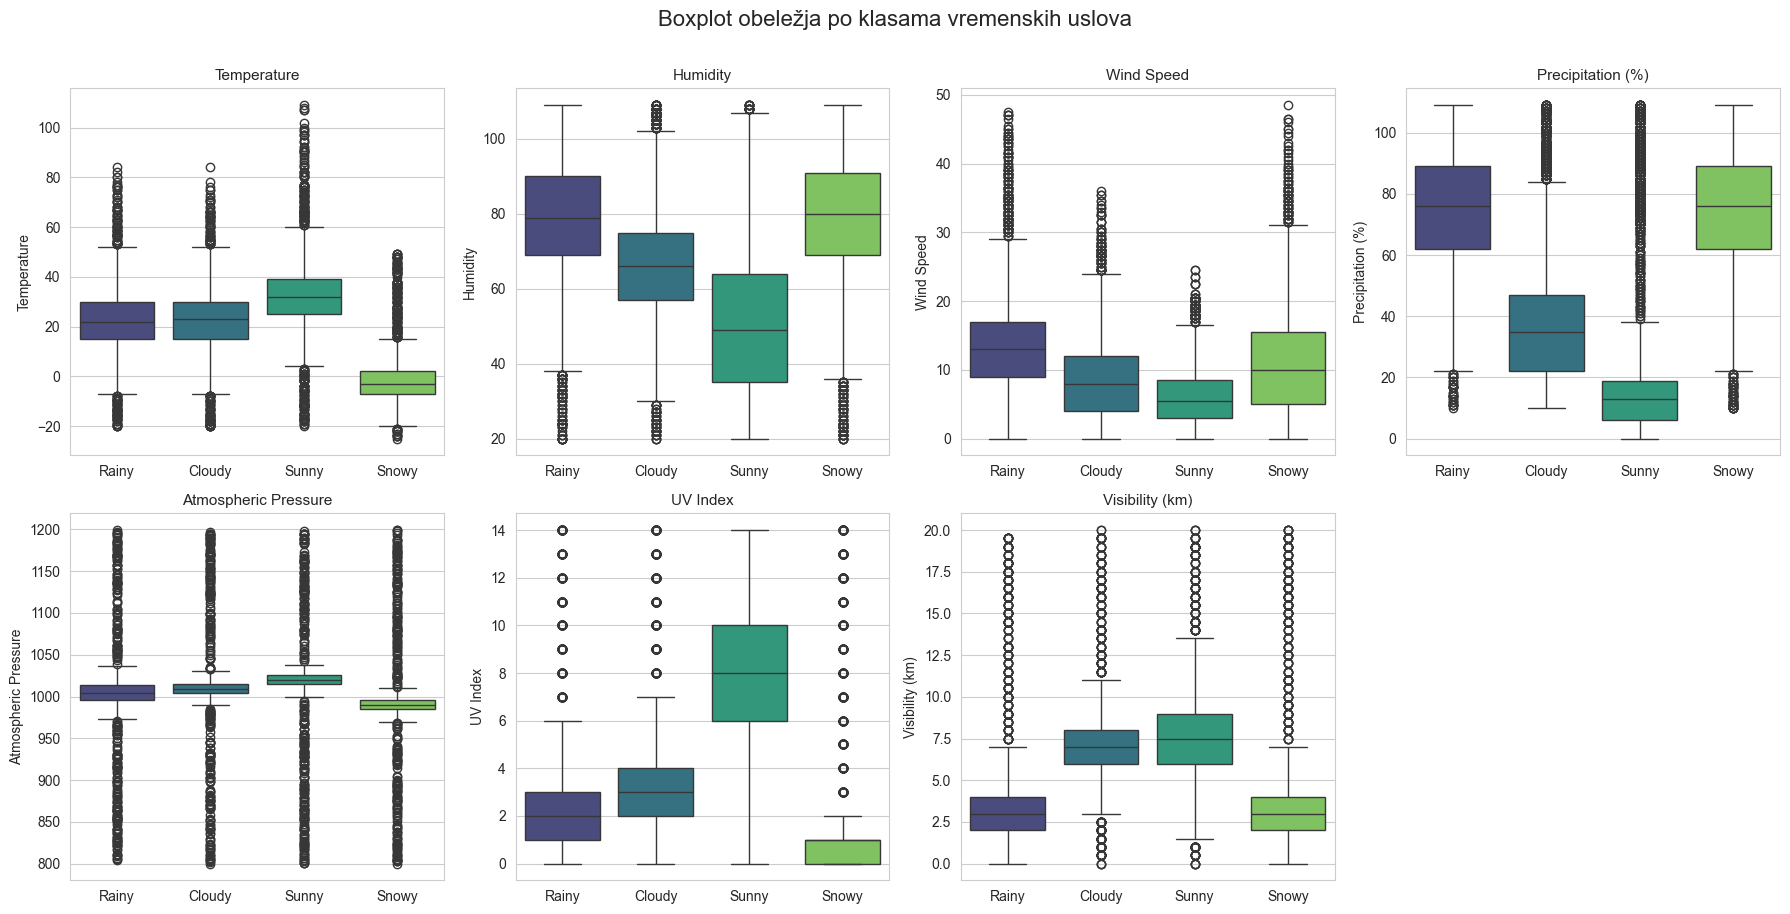

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Weather Type', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplot obeležja po klasama vremenskih uslova', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

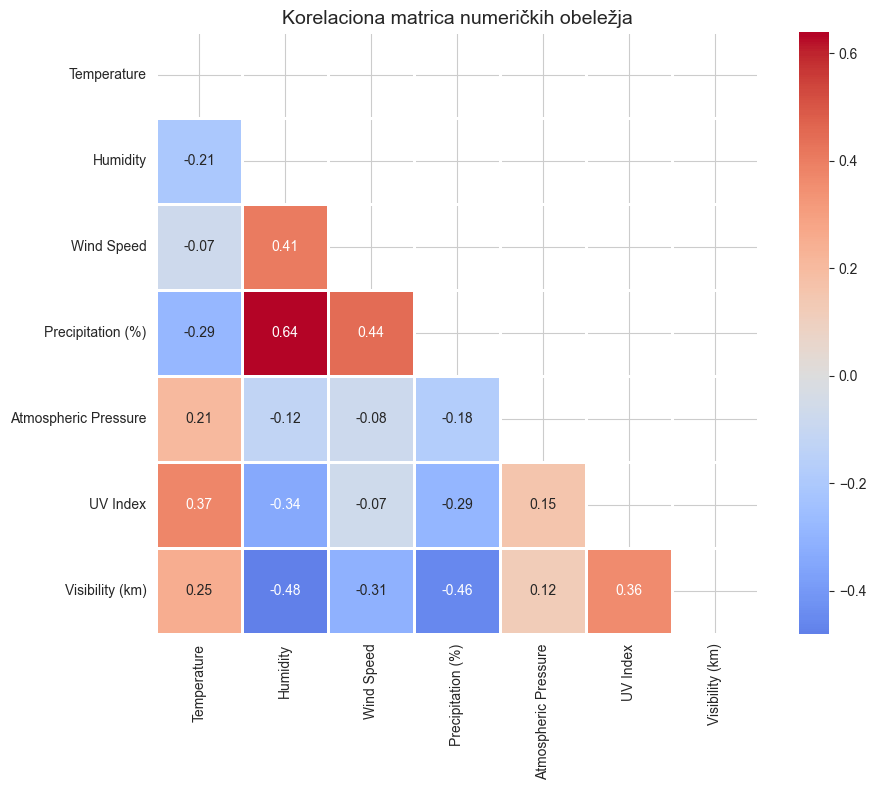

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Korelaciona matrica numeričkih obeležja', fontsize=14)
plt.tight_layout()
plt.show()

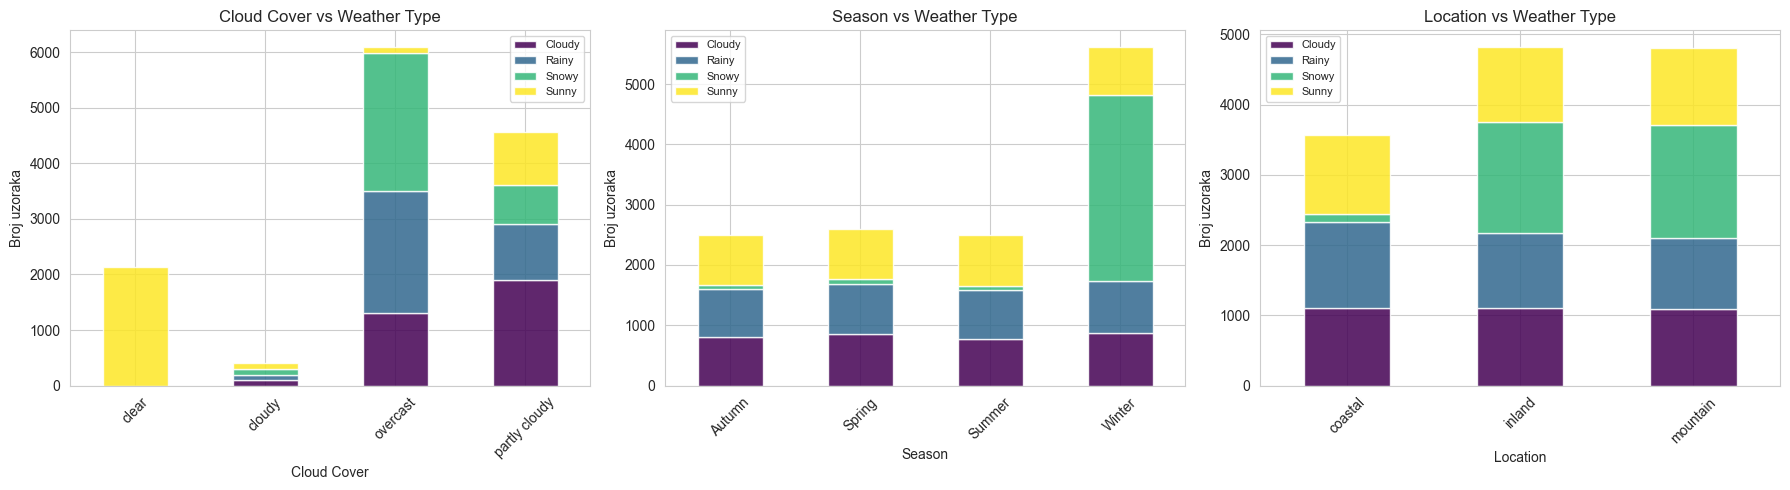

In [ ]:
cat_cols = ['Cloud Cover', 'Season', 'Location']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Weather Type'])
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', alpha=0.85)
    axes[i].set_title(f'{col} vs Weather Type', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Priprema podataka

1. **Label Encoding** kategoričkih obeležja (`Cloud Cover`, `Season`, `Location`)
2. **Standardizacija** (StandardScaler) numeričkih obeležja, neuronske mreže su osetljive na skalu podataka
3. **Podela** na trening (70%), validacioni (15%) i test (15%) skup
4. **One-hot encoding** ciljne promenljive za Keras model

In [ ]:
label_encoders = {}
for col in ['Cloud Cover', 'Season', 'Location']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

le_target = LabelEncoder()
df['Weather Type Encoded'] = le_target.fit_transform(df['Weather Type'])
class_names = le_target.classes_
n_classes = len(class_names)
print(f"\nCiljne klase: {dict(zip(class_names, le_target.transform(class_names)))}")
print(f"Broj klasa: {n_classes}")

Cloud Cover: {'clear': np.int64(0), 'cloudy': np.int64(1), 'overcast': np.int64(2), 'partly cloudy': np.int64(3)}
Season: {'Autumn': np.int64(0), 'Spring': np.int64(1), 'Summer': np.int64(2), 'Winter': np.int64(3)}
Location: {'coastal': np.int64(0), 'inland': np.int64(1), 'mountain': np.int64(2)}

Ciljne klase: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}
Broj klasa: 4


In [ ]:
feature_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
                'Visibility (km)', 'Location']

X = df[feature_cols].values
y = df['Weather Type Encoded'].values

print(f"Ulazna dimenzija: {X.shape}")
print(f"Izlazna dimenzija: {y.shape}")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"\nTrening skup:      {X_train.shape[0]} uzoraka ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validacioni skup:  {X_val.shape[0]} uzoraka ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test skup:         {X_test.shape[0]} uzoraka ({X_test.shape[0]/len(X)*100:.1f}%)")

Ulazna dimenzija: (13200, 10)
Izlazna dimenzija: (13200,)

Trening skup:      9245 uzoraka (70.0%)
Validacioni skup:  1975 uzoraka (15.0%)
Test skup:         1980 uzoraka (15.0%)


In [13]:
# Standardizacija obeležja
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Srednje vrednosti trening skupa nakon skaliranja (≈0):")
print(np.round(X_train.mean(axis=0), 4))
print("\nStandardne devijacije trening skupa nakon skaliranja (≈1):")
print(np.round(X_train.std(axis=0), 4))

Srednje vrednosti trening skupa nakon skaliranja (≈0):
[ 0.  0.  0.  0. -0.  0.  0. -0. -0.  0.]

Standardne devijacije trening skupa nakon skaliranja (≈1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [14]:
# One-hot encoding ciljne promenljive za Keras
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_val_cat = to_categorical(y_val, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

print(f"One-hot shape (trening): {y_train_cat.shape}")
print(f"Primer: klasa {y_train[0]} → {y_train_cat[0]}")

One-hot shape (trening): (9245, 4)
Primer: klasa 3 → [0. 0. 0. 1.]


## 4. Model 1 — MLPClassifier (scikit-learn)

`MLPClassifier` iz scikit-learn biblioteke sa:
- **Arhitektura:** 3 skrivena sloja (128, 64, 32 neurona)
- **Aktivaciona funkcija:** ReLU
- **Optimizator:** Adam
- **Regularizacija:** L2 (alpha=0.001)
- **Maks. iteracija:** 300 epoha

In [15]:
# Kreiranje i treniranje MLPClassifier modela
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

mlp_sklearn.fit(X_train, y_train)
print(f"\nBroj iteracija: {mlp_sklearn.n_iter_}")
print(f"Krajnji loss: {mlp_sklearn.loss_:.4f}")

Iteration 1, loss = 0.58935881
Validation score: 0.909877
Iteration 2, loss = 0.30092630
Validation score: 0.910598
Iteration 3, loss = 0.24993291
Validation score: 0.917087
Iteration 4, loss = 0.22640865
Validation score: 0.911319
Iteration 5, loss = 0.20894447
Validation score: 0.915645
Iteration 6, loss = 0.19830795
Validation score: 0.912040
Iteration 7, loss = 0.19191574
Validation score: 0.916366
Iteration 8, loss = 0.18274121
Validation score: 0.909156
Iteration 9, loss = 0.18057833
Validation score: 0.913482
Iteration 10, loss = 0.17491527
Validation score: 0.912761
Iteration 11, loss = 0.17105999
Validation score: 0.912040
Iteration 12, loss = 0.16535930
Validation score: 0.909156
Iteration 13, loss = 0.16126873
Validation score: 0.917808
Iteration 14, loss = 0.16123367
Validation score: 0.914924
Iteration 15, loss = 0.15468504
Validation score: 0.910598
Iteration 16, loss = 0.15307406
Validation score: 0.912761
Iteration 17, loss = 0.14939052
Validation score: 0.911319
Iterat

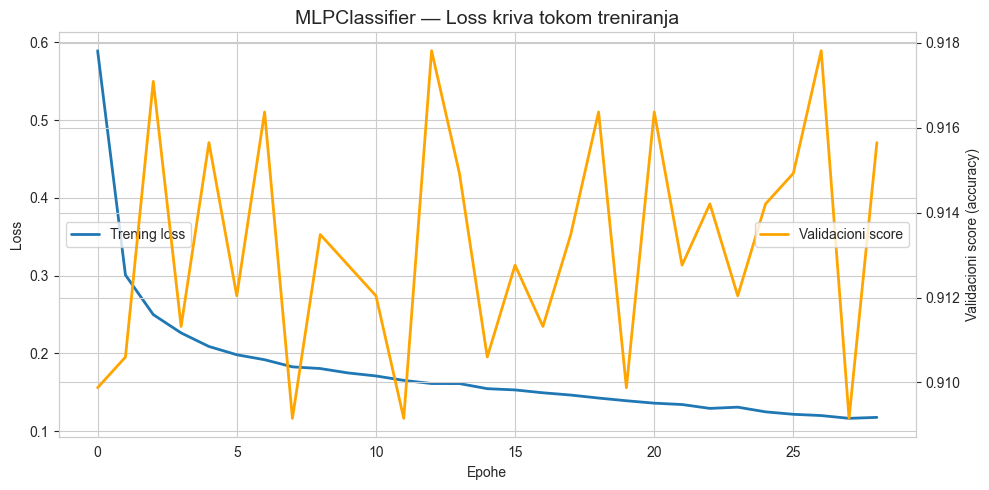

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_sklearn.loss_curve_, label='Trening loss', linewidth=2)
if hasattr(mlp_sklearn, 'validation_scores_'):
    ax2 = ax.twinx()
    ax2.plot(mlp_sklearn.validation_scores_, label='Validacioni score', color='orange', linewidth=2)
    ax2.set_ylabel('Validacioni score (accuracy)')
    ax2.legend(loc='center right')
ax.set_xlabel('Epohe')
ax.set_ylabel('Loss')
ax.set_title('MLPClassifier — Loss kriva tokom treniranja', fontsize=14)
ax.legend(loc='center left')
plt.tight_layout()
plt.show()

MLPClassifier (scikit-learn) — Rezultati na test skupu

Tačnost (Accuracy): 0.8995

Klasifikacioni izveštaj:
              precision    recall  f1-score   support

      Cloudy       0.82      0.91      0.86       495
       Rainy       0.87      0.91      0.89       495
       Snowy       0.99      0.88      0.93       495
       Sunny       0.94      0.90      0.92       495

    accuracy                           0.90      1980
   macro avg       0.91      0.90      0.90      1980
weighted avg       0.91      0.90      0.90      1980



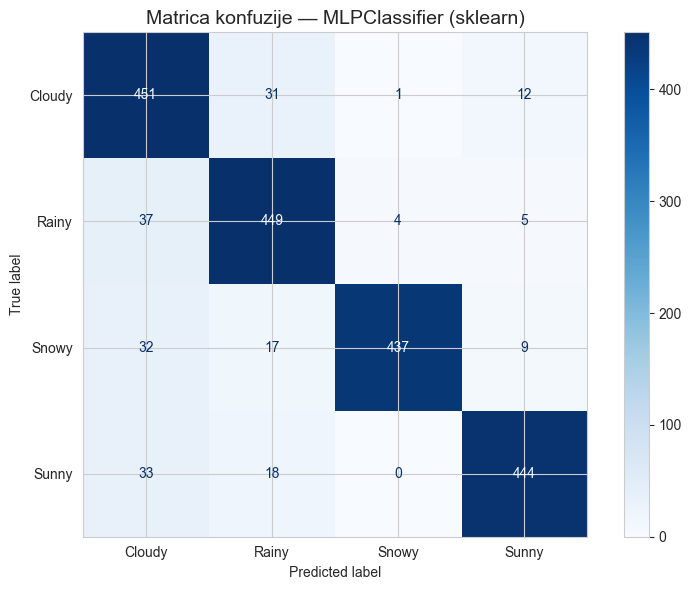

In [ ]:
y_pred_sklearn = mlp_sklearn.predict(X_test)

print("MLPClassifier (scikit-learn) — Rezultati na test skupu")
print(f"\nTačnost (Accuracy): {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"\nKlasifikacioni izveštaj:")
print(classification_report(y_test, y_pred_sklearn, target_names=class_names))

# Matrica konfuzije
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_sklearn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matrica konfuzije — MLPClassifier (sklearn)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Model 2 — Keras Sequential neuronska mreža (TensorFlow)

Keras model sa sledećom arhitekturom:
- **Ulazni sloj:** 10 obeležja
- **Skriveni sloj 1:** 128 neurona, ReLU, BatchNormalization, Dropout(0.3)
- **Skriveni sloj 2:** 64 neurona, ReLU, BatchNormalization, Dropout(0.3)
- **Skriveni sloj 3:** 32 neurona, ReLU, BatchNormalization, Dropout(0.2)
- **Izlazni sloj:** 4 neurona (softmax) — za 4 klase

**Loss funkcija:** Categorical Crossentropy (standardna loss funkcija za multi-class klasifikaciju).

**Optimizator:** Adam sa learning rate = 0.001

**Callback:** EarlyStopping — zaustavlja treniranje kada se validacioni loss ne poboljšava 15 epoha.

In [ ]:
n_features = X_train.shape[1]

keras_model = Sequential([
    # Skriveni sloj 1
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Skriveni sloj 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Skriveni sloj 3
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Izlazni sloj — softmax za multi-class klasifikaciju
    Dense(n_classes, activation='softmax')
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,772 (49.89 KB)

 Trainable params: 12,324 (48.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Treniranje Keras modela
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = keras_model.fit(
    X_train, y_train_cat,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTreniranje završeno nakon {len(history.history['loss'])} epoha.")

Epoch 1/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7572 - loss: 0.7058 - val_accuracy: 0.8780 - val_loss: 0.4993
Epoch 2/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.8599 - loss: 0.4128 - val_accuracy: 0.8906 - val_loss: 0.3112
Epoch 3/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.8774 - loss: 0.3409 - val_accuracy: 0.8982 - val_loss: 0.2699
Epoch 4/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.8856 - loss: 0.3110 - val_accuracy: 0.8967 - val_loss: 0.2580
Epoch 5/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.8911 - loss: 0.2899 - val_accuracy: 0.8947 - val_loss: 0.2419
Epoch 6/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.8909 - loss: 0.2806 - val_accuracy: 0.8967 - val_loss: 0.2356
Epoch 7/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - accuracy: 0.8937 - loss: 0.2674 - val_accuracy: 0.8992 - val_loss: 0.2367
Epoch 8/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - accuracy: 0.8981 - loss: 0.2

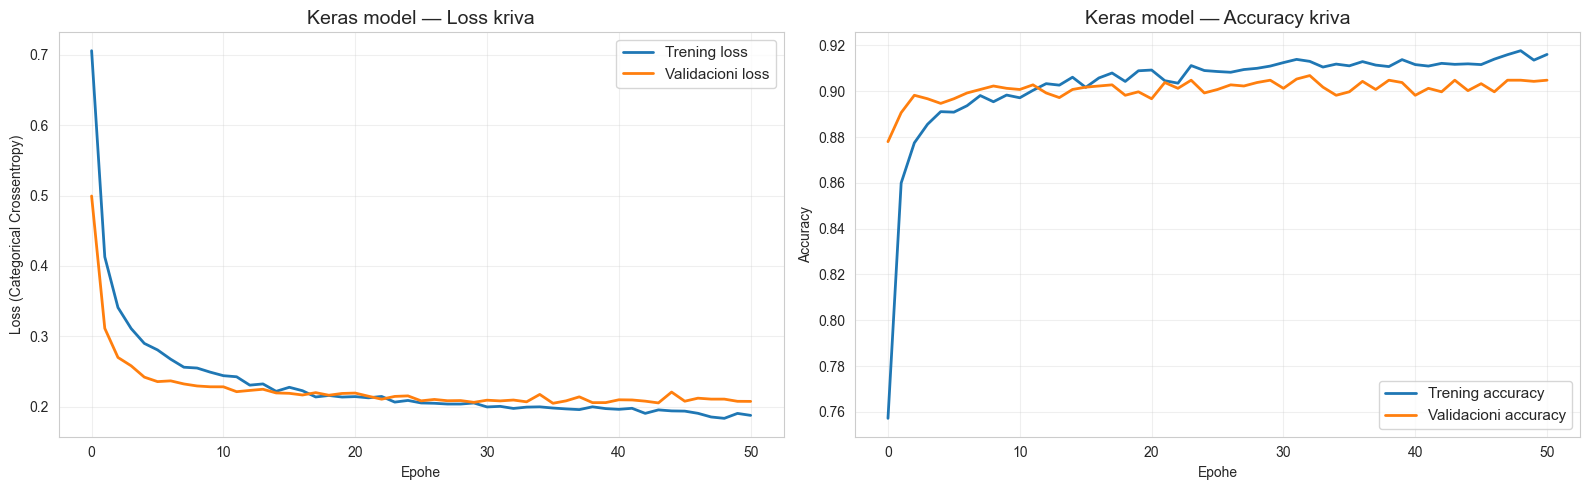

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss kriva
axes[0].plot(history.history['loss'], label='Trening loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validacioni loss', linewidth=2)
axes[0].set_xlabel('Epohe')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].set_title('Keras model — Loss kriva', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy kriva
axes[1].plot(history.history['accuracy'], label='Trening accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validacioni accuracy', linewidth=2)
axes[1].set_xlabel('Epohe')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Keras model — Accuracy kriva', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Keras model — Test loss: 0.1923
Keras model — Test accuracy: 0.9086
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step

Keras Sequential model — Rezultati na test skupu

Tačnost (Accuracy): 0.9086

Klasifikacioni izveštaj:
              precision    recall  f1-score   support

      Cloudy       0.88      0.90      0.89       495
       Rainy       0.84      0.94      0.89       495
       Snowy       0.98      0.89      0.93       495
       Sunny       0.95      0.91      0.93       495

    accuracy                           0.91      1980
   macro avg       0.91      0.91      0.91      1980
weighted avg       0.91      0.91      0.91      1980



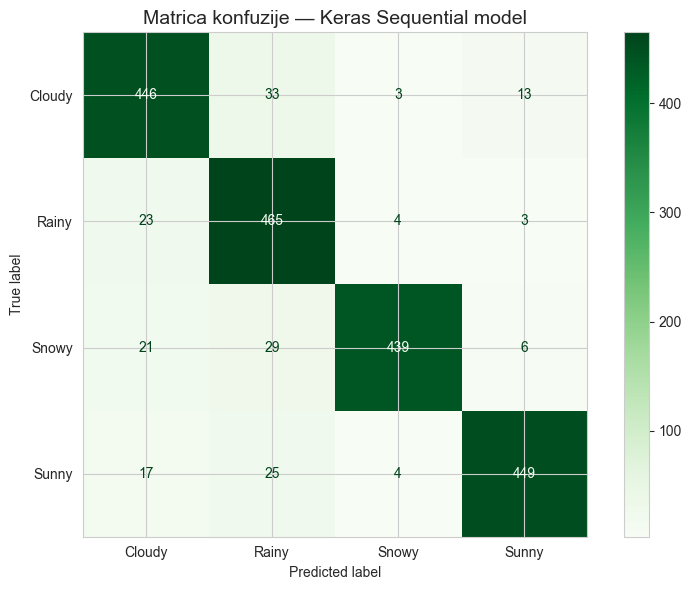

In [21]:
# Evaluacija Keras modela na test skupu
test_loss, test_acc = keras_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Keras model — Test loss: {test_loss:.4f}")
print(f"Keras model — Test accuracy: {test_acc:.4f}")

# Predikcije
y_pred_keras_prob = keras_model.predict(X_test)
y_pred_keras = np.argmax(y_pred_keras_prob, axis=1)

print(f"\n{'='*60}")
print("Keras Sequential model — Rezultati na test skupu")
print(f"{'='*60}")
print(f"\nTačnost (Accuracy): {accuracy_score(y_test, y_pred_keras):.4f}")
print(f"\nKlasifikacioni izveštaj:")
print(classification_report(y_test, y_pred_keras, target_names=class_names))

# Matrica konfuzije
fig, ax = plt.subplots(figsize=(8, 6))
cm_keras = confusion_matrix(y_test, y_pred_keras)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=class_names)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Matrica konfuzije — Keras Sequential model', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Poređenje modela i dodatna vizuelizacija

Poređenje modela na test skupu:
                                Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Model                                                                                        
MLPClassifier\n(scikit-learn)     0.8995             0.9052          0.8995            0.9007
Keras Sequential\n(TensorFlow)    0.9086             0.9127          0.9086            0.9093


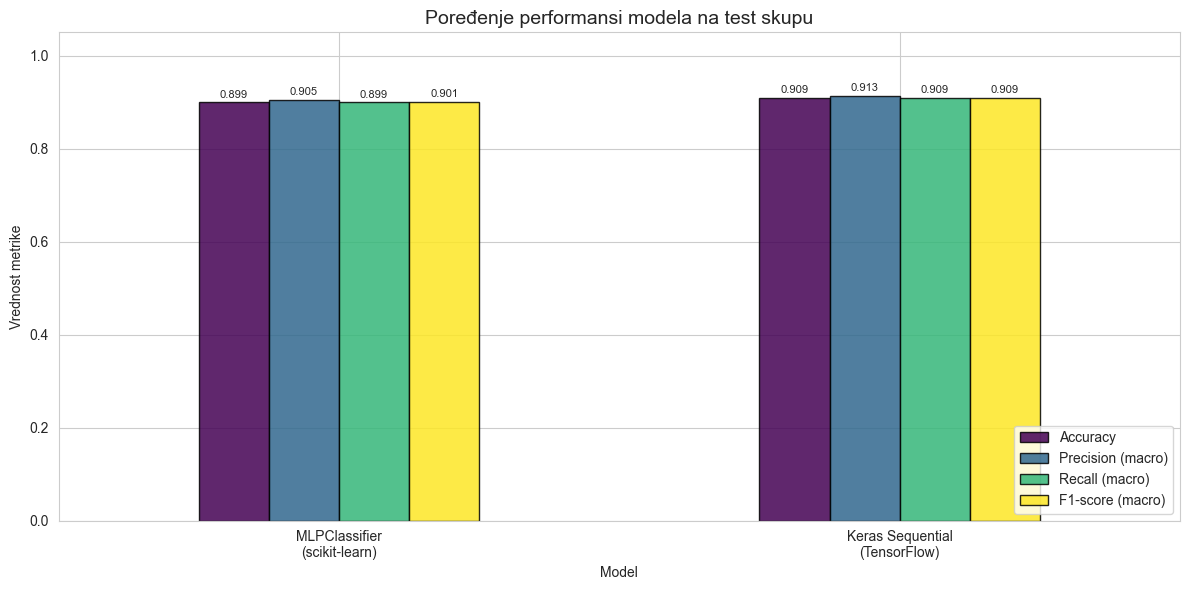

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = ['MLPClassifier\n(scikit-learn)', 'Keras Sequential\n(TensorFlow)']
predictions = [y_pred_sklearn, y_pred_keras]

results = []
for name, y_pred in zip(models, predictions):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_test, y_pred, average='macro')
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Poređenje modela na test skupu:")
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis', alpha=0.85, edgecolor='black')
ax.set_title('Poređenje performansi modela na test skupu', fontsize=14)
ax.set_ylabel('Vrednost metrike')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

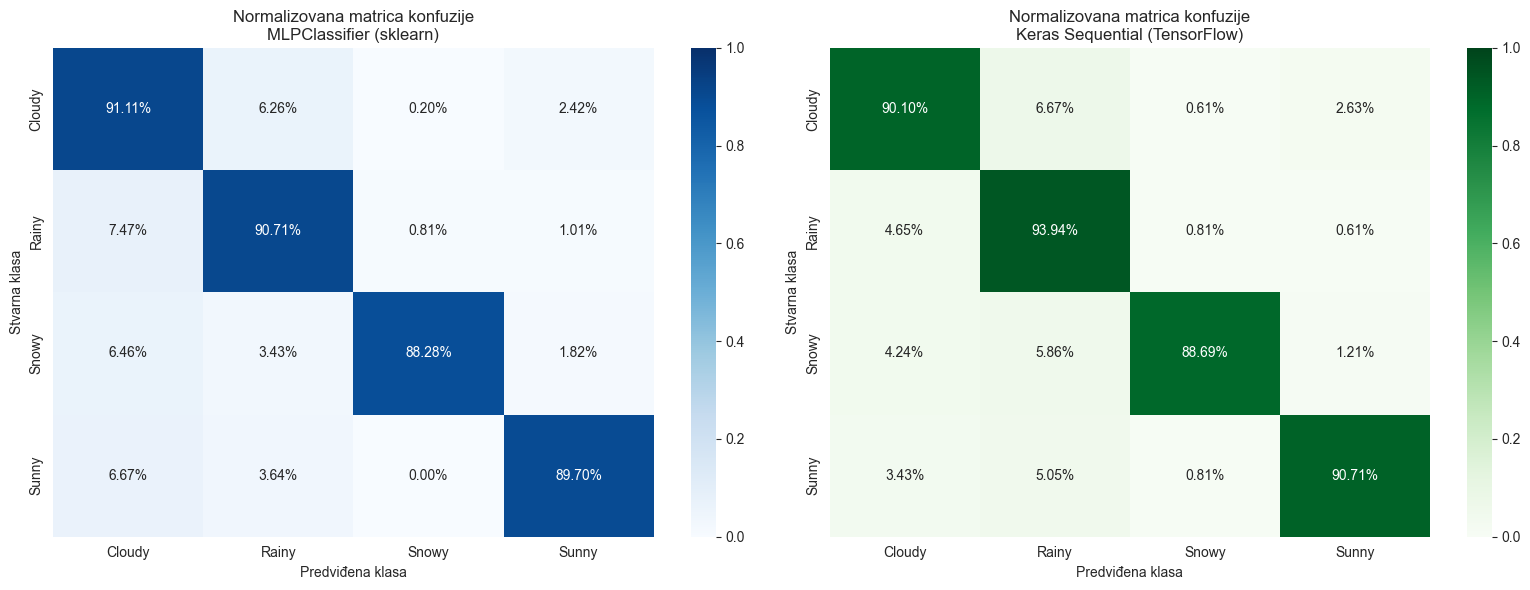

In [23]:
# Uporedne matrice konfuzije
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm_data, title, cmap in zip(
    axes,
    [cm, cm_keras],
    ['MLPClassifier (sklearn)', 'Keras Sequential (TensorFlow)'],
    ['Blues', 'Greens']
):
    # Normalizovana matrica konfuzije (po redovima)
    cm_norm = cm_data.astype('float') / cm_data.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap=cmap, xticklabels=class_names,
                yticklabels=class_names, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'Normalizovana matrica konfuzije\n{title}', fontsize=12)
    ax.set_ylabel('Stvarna klasa')
    ax.set_xlabel('Predviđena klasa')

plt.tight_layout()
plt.show()

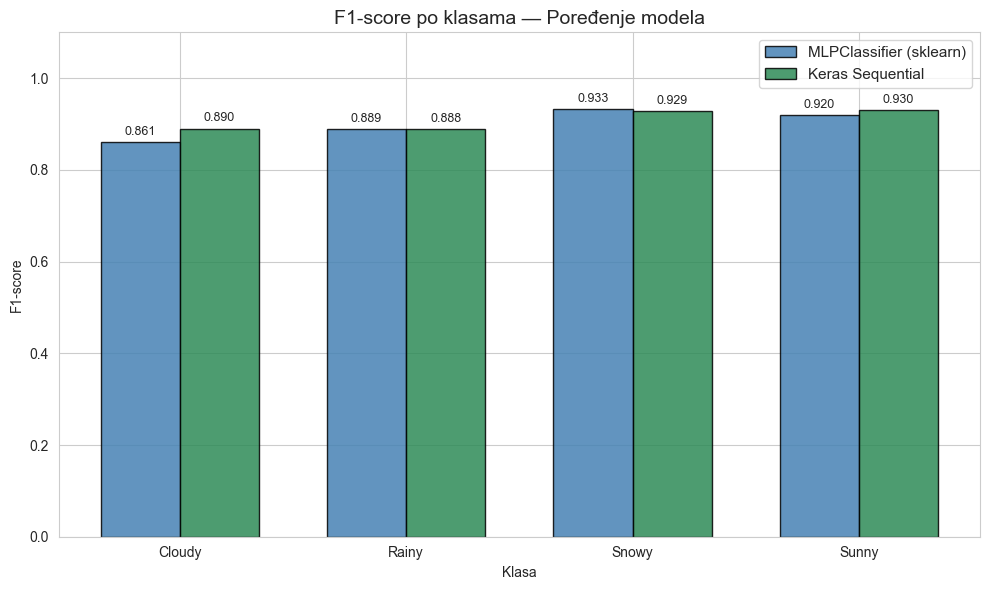

In [24]:
# Per-class F1 score poređenje
from sklearn.metrics import f1_score as f1_func

f1_sklearn = f1_func(y_test, y_pred_sklearn, average=None)
f1_keras = f1_func(y_test, y_pred_keras, average=None)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(n_classes)
width = 0.35

bars1 = ax.bar(x - width/2, f1_sklearn, width, label='MLPClassifier (sklearn)',
               color='steelblue', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, f1_keras, width, label='Keras Sequential',
               color='seagreen', alpha=0.85, edgecolor='black')

ax.set_xlabel('Klasa')
ax.set_ylabel('F1-score')
ax.set_title('F1-score po klasama — Poređenje modela', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)

ax.bar_label(bars1, fmt='%.3f', fontsize=9, padding=3)
ax.bar_label(bars2, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

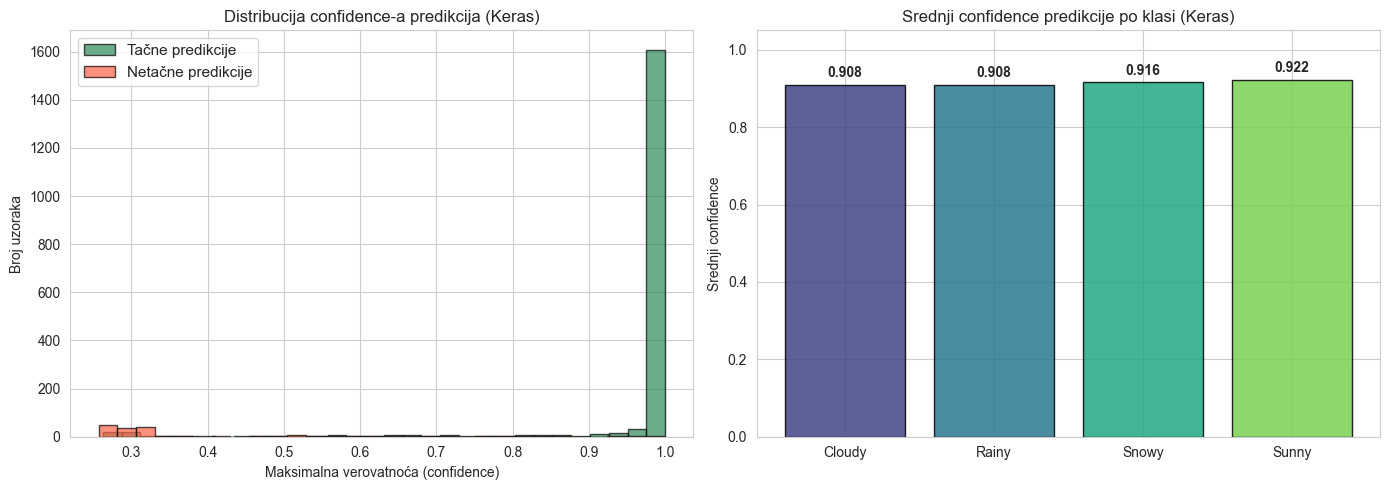

In [25]:
# Vizuelizacija predikcija Keras modela — distribucija verovatnoća (confidence)
max_probs = np.max(y_pred_keras_prob, axis=1)
correct_mask = y_pred_keras == y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucija confidence-a za tačne i netačne predikcije
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.7, label='Tačne predikcije',
             color='seagreen', edgecolor='black')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7, label='Netačne predikcije',
             color='tomato', edgecolor='black')
axes[0].set_xlabel('Maksimalna verovatnoća (confidence)')
axes[0].set_ylabel('Broj uzoraka')
axes[0].set_title('Distribucija confidence-a predikcija (Keras)', fontsize=12)
axes[0].legend(fontsize=11)

# Srednji confidence po klasi
mean_conf_per_class = []
for cls in range(n_classes):
    mask = y_test == cls
    mean_conf_per_class.append(max_probs[mask].mean())

axes[1].bar(class_names, mean_conf_per_class, color=sns.color_palette('viridis', n_classes),
            edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Srednji confidence')
axes[1].set_title('Srednji confidence predikcije po klasi (Keras)', fontsize=12)
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(mean_conf_per_class):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()